In [ ]:
!pip install segmentation_models

In [2]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io import loadmat
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from pathlib import Path
import h5py

## Data Loading and Preprocessing

### Loading

In [19]:
# Define paths for Kaggle
BASE_PATH = '../input/brain-tumor/brain_tumor'  # Default Kaggle dataset input path
OUTPUT_PATH = '/kaggle/working/'  # Kaggle working directory
os.makedirs(os.path.join(OUTPUT_PATH, 'data_segmentation'), exist_ok=True)

# Image preprocessing functions
def enhance_contrast(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image.astype(np.uint8))

def remove_noise(image):
    return cv2.medianBlur(image.astype(np.uint8), 3)

def standardize_image(image):
    mean = np.mean(image)
    std = np.std(image)
    if std == 0:
        return image - mean
    return (image - mean) / std

def enhance_preprocessing(image, mask):
    """
    Enhance image contrast with CLAHE and ensure mask is binary.
    Expects image as float32 in [0,1] and mask as uint8 or bool.
    Returns processed image (float32 [0,1]) and binary mask (uint8 {0,1}).
    """
    # CLAHE expects uint8 input:
    img_uint8 = (image * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_uint8)
    enhanced = enhanced.astype(np.float32) / 255.0
    binary_mask = (mask > 0).astype(np.uint8)
    return enhanced, binary_mask

def load_mat_file(filepath):
    """
    Load a .mat file: try HDF5 (v7.3) then fallback to scipy.io.loadmat.
    Returns image (float32), mask (uint8), label (int), or (None,None,None) on failure.
    """
    # Attempt HDF5 (.mat v7.3)
    try:
        with h5py.File(filepath, 'r') as f:
            image = np.array(f['cjdata/image']).T
            mask  = np.array(f['cjdata/tumorMask']).T
            label = int(f['cjdata/label'][0][0])
    except (OSError, KeyError, ValueError):
        # Fallback to scipy.loadmat for older .mat formats
        try:
            data = loadmat(filepath)
            cj = data.get('cjdata', None)
            if cj is None:
                return None, None, None
            image = cj['image'][0,0]
            mask  = cj['tumorMask'][0,0]
            label = int(cj['label'][0,0])
        except Exception:
            return None, None, None

    # Normalize image to [0,1]
    image = image.astype(np.float32)
    min_val, max_val = image.min(), image.max()
    if max_val > min_val:
        image = (image - min_val) / (max_val - min_val)
    else:
        image = image - min_val

    mask = mask.astype(np.uint8)
    return image, mask, label


def load_data(mat_folder, img_size=(128, 128)):
    """
    Load all .mat files from folder, preprocess, resize, and add channel dims.
    Skips files that do not contain valid 'cjdata'.
    Returns numpy arrays X: (N, H, W, 1), y: (N, H, W, 1).
    """
    images, masks = [], []
    for fname in sorted(os.listdir(mat_folder)):
        if not fname.endswith('.mat'):
            continue
        path = os.path.join(mat_folder, fname)
        image, mask, _ = load_mat_file(path)
        if image is None or mask is None:
            continue
        # Enhance and binarize
        image, mask = enhance_preprocessing(image, mask)
        # Resize
        image = cv2.resize(image, img_size, interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
        # Add channel axis
        images.append(image[..., np.newaxis])
        masks.append(mask[..., np.newaxis])

    X = np.stack(images, axis=0).astype(np.float32)
    y = np.stack(masks, axis=0).astype(np.uint8)
    return X, y

# Paths (adjust for your environment)
MAT_FOLDER  = '../input/brain-tumor/brain_tumor'
print("Loading and preprocessing data...")
X, y = load_data(MAT_FOLDER)
print(f"Data shapes: X={X.shape}, y={y.shape}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train/Test split: X_train={X_train.shape}, X_test={X_test.shape}")

Loading and preprocessing data...
Data shapes: X=(3064, 128, 128, 1), y=(3064, 128, 128, 1)
Train/Test split: X_train=(2451, 128, 128, 1), X_test=(613, 128, 128, 1)


### Classification and Segmentation Data

In [10]:
# Load segmentation data
def load_segmentation_data(data_dir, img_size=(128, 128)):
    images, masks = [], []
    for file in Path(data_dir).glob('*_image.npy'):
        base_name = file.stem.replace('_image', '')
        img = np.load(file)
        mask = np.load(os.path.join(data_dir, f"{base_name}_mask.npy"))
        
        img = cv2.resize(img, img_size)
        mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
        
        images.append(img)
        masks.append(mask)
    return np.array(images), np.array(masks)

In [11]:
# Prepare segmentation data
print("\nPreparing segmentation data...")
seg_X, seg_y = load_segmentation_data(os.path.join(OUTPUT_PATH, 'data_segmentation'))
seg_X = seg_X / 255.0
seg_y = (seg_y > 0).astype(np.uint8)
seg_X_train, seg_X_test, seg_y_train, seg_y_test = train_test_split(seg_X, seg_y, test_size=0.2, random_state=42)

# Print dataset summaries
print("\nDataset Summary:")
print(f"Segmentation - Training: {seg_X_train.shape}, Testing: {seg_X_test.shape}")

# Save processed data for quick loading
np.save(os.path.join(OUTPUT_PATH, 'seg_X_train.npy'), seg_X_train)
np.save(os.path.join(OUTPUT_PATH, 'seg_X_test.npy'), seg_X_test)
np.save(os.path.join(OUTPUT_PATH, 'seg_y_train.npy'), seg_y_train)
np.save(os.path.join(OUTPUT_PATH, 'seg_y_test.npy'), seg_y_test)


Preparing segmentation data...

Dataset Summary:
Segmentation - Training: (2451, 128, 128), Testing: (613, 128, 128)


In [34]:
def save_model_architectures(segnet, unet):
    # save PNGs of each architecture with shapes & layer names
    plot_model(segnet, to_file=os.path.join(OUTPUT_PATH, 'segnet_architecture.png'),
               show_shapes=True, show_layer_names=False)
    plot_model(unet, to_file=os.path.join(OUTPUT_PATH, 'attention_unet_architecture.png'),
               show_shapes=True, show_layer_names=False)
    print("Saved model architectures.")

def save_training_curves(history, name):
    # Loss curve
    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{name}_loss_curve.png'))
    plt.close()

    # Dice coefficient curve
    plt.figure()
    plt.plot(history.history['dice_coef'], label='train_dice')
    plt.plot(history.history['val_dice_coef'], label='val_dice')
    plt.title('Dice Coefficient')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{name}_dice_curve.png'))
    plt.close()

    print(f"Saved training curves for {name}.")

def save_classification_metrics_and_confusion(model, X_val, y_val, name, threshold=0.2):
    preds = model.predict(X_val)
    
    # Flatten masks to binary vectors
    y_true = (y_val > 0).astype(int).flatten()
    y_pred = (preds >= threshold).astype(int).flatten()

    from sklearn.metrics import classification_report, confusion_matrix
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    print(f"Classification report for {name}:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'{name}_confusion_matrix.png')
    plt.close()

def save_validation_predictions(model, X_val, y_val, name, num=3, threshold=0.2):
    preds = model.predict(X_val[:num])
    # one figure with num rows
    fig, axes = plt.subplots(num, 3, figsize=(12, 4*num))
    for i in range(num):
        axes[i,0].imshow(X_val[i].squeeze(), cmap='gray')
        axes[i,0].set_title('Input')
        axes[i,0].axis('off')

        axes[i,1].imshow(y_val[i].squeeze(), cmap='gray')
        axes[i,1].set_title('Ground Truth')
        axes[i,1].axis('off')

        mask = (preds[i].squeeze() >= threshold).astype(np.uint8)
        axes[i,2].imshow(mask, cmap='gray')
        axes[i,2].set_title('Predicted')
        axes[i,2].axis('off')

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, f'{name}_val_vs_pred.png'))
    plt.close()
    print(f"Saved validation preds vs labels for {name}.")


## Models

In [13]:
#SegNet Implementation
def build_segnet(input_shape=(128, 128, 1)):
    # Encoder
    inputs = Input(shape=input_shape)
    
    # Encoder block 1
    x = layers.Conv2D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    
    # Encoder block 2
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    
    # Decoder block 1
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Decoder block 2
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    
    return Model(inputs, outputs)

In [14]:
def attention_gate(x, g, inter_channel):
    """Attention gate for skip connections in U-Net"""
    theta_x = layers.Conv2D(inter_channel, 1, padding='same')(x)
    phi_g = layers.Conv2D(inter_channel, 1, padding='same')(g)
    
    concat = layers.add([theta_x, phi_g])
    relu = layers.Activation('relu')(concat)
    
    psi = layers.Conv2D(1, 1, padding='same')(relu)
    sigmoid = layers.Activation('sigmoid')(psi)
    
    return layers.multiply([x, sigmoid])

def build_attention_unet(input_shape=(128, 128, 1)):
    inputs = Input(shape=input_shape)
    
    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)
    
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)
    
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)
    
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D()(c4)
    
    # Bridge
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)
    
    # Decoder with attention gates
    u6 = layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(c5)
    a6 = attention_gate(c4, u6, 256)
    u6 = layers.concatenate([u6, a6])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(c6)
    a7 = attention_gate(c3, u7, 128)
    u7 = layers.concatenate([u7, a7])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)
    
    u8 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(c7)
    a8 = attention_gate(c2, u8, 64)
    u8 = layers.concatenate([u8, a8])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)
    
    u9 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c8)
    a9 = attention_gate(c1, u9, 32)
    u9 = layers.concatenate([u9, a9])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)
    
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)
    
    return Model(inputs=inputs, outputs=outputs)

In [15]:
# --- 3. Losses & Metrics ---

import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1.0):
    """Dice loss for binary segmentation."""
    # ensure y_true is float32
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1.0 - ((2.0 * intersection + smooth) /
                  (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth))


def dice_coef(y_true, y_pred, smooth=1.0):
    """Dice coefficient metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )


def weighted_bce_loss(y_true, y_pred, weight_factor=10.0):
    """Weighted binary cross‑entropy: positive class gets higher weight."""
    # cast y_true so multiplications produce float32 weights
    y_true_f = tf.cast(y_true, tf.float32)
    # pixel‑wise weights: weight_factor for tumor pixels, 1 for background
    weights = y_true_f * (weight_factor - 1.0) + 1.0
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    return bce(y_true_f, y_pred, sample_weight=weights)


def combined_loss(y_true, y_pred):
    """Combine Dice loss and weighted BCE."""
    return 0.5 * dice_loss(y_true, y_pred) + 0.5 * weighted_bce_loss(y_true, y_pred)


def custom_precision(y_true, y_pred, threshold=0.2):
    """Precision with lower threshold for positive class."""
    # ensure y_true is float32
    y_true = tf.cast(y_true, tf.float32)
    # threshold predictions
    y_pred_thr = tf.cast(y_pred >= threshold, tf.float32)
    tp = tf.keras.backend.sum(y_true * y_pred_thr)
    pp = tf.keras.backend.sum(y_pred_thr)
    return tp / (pp + tf.keras.backend.epsilon())


def custom_recall(y_true, y_pred, threshold=0.2):
    """Recall with lower threshold for positive class."""
    # ensure y_true is float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred_thr = tf.cast(y_pred >= threshold, tf.float32)
    tp = tf.keras.backend.sum(y_true * y_pred_thr)
    pos = tf.keras.backend.sum(y_true)
    return tp / (pos + tf.keras.backend.epsilon())


def custom_iou(y_true, y_pred, threshold=0.2):
    """IoU with lower threshold for positive class."""
    # ensure y_true is float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred_thr = tf.cast(y_pred >= threshold, tf.float32)
    inter = tf.keras.backend.sum(y_true * y_pred_thr)
    union = tf.keras.backend.sum(y_true) + tf.keras.backend.sum(y_pred_thr) - inter
    return inter / (union + tf.keras.backend.epsilon())


In [16]:
# --- 4. Visualization ---

def visualize_predictions(model, X, y, num=3, threshold=0.2):
    preds = model.predict(X[:num])
    fig, axes = plt.subplots(num, 3, figsize=(12, 4 * num))
    for i in range(num):
        axes[i,0].imshow(X[i].squeeze(), cmap='gray'); axes[i,0].set_title('Input')
        axes[i,1].imshow(y[i].squeeze(), cmap='gray'); axes[i,1].set_title('Ground Truth')
        mask = (preds[i].squeeze() >= threshold).astype(np.uint8)
        axes[i,2].imshow(mask, cmap='gray'); axes[i,2].set_title('Predicted')
    plt.tight_layout(); plt.show()


def plot_training_curves(history):
    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss'); plt.legend(); plt.show()

    plt.figure()
    plt.plot(history.history['dice_coef'], label='train_dice')
    plt.plot(history.history['val_dice_coef'], label='val_dice')
    plt.title('Dice Coefficient'); plt.legend(); plt.show()


## Training

Epoch 1/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 110ms/step - accuracy: 0.7468 - custom_iou: 0.0241 - custom_precision: 0.0241 - custom_recall: 0.9869 - dice_coef: 0.0573 - loss: 0.7790 - val_accuracy: 0.9829 - val_custom_iou: 0.0173 - val_custom_precision: 0.0173 - val_custom_recall: 1.0000 - val_dice_coef: 0.0322 - val_loss: 0.7520 - learning_rate: 1.0000e-04
Epoch 2/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9473 - custom_iou: 0.0795 - custom_precision: 0.0802 - custom_recall: 0.9206 - dice_coef: 0.1176 - loss: 0.5897 - val_accuracy: 0.5908 - val_custom_iou: 0.0068 - val_custom_precision: 0.0070 - val_custom_recall: 0.2406 - val_dice_coef: 0.0140 - val_loss: 1.0173 - learning_rate: 1.0000e-04
Epoch 3/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9611 - custom_iou: 0.1304 - custom_precision: 0.1329 - custom_recall: 0.8907 - dice_coef: 0.1675 - loss: 0.5335 - val_accuracy: 0.3544 - val_custom_iou: 0.0186 - val_custom_precision: 0.0187 - val_custom_recall: 0.858

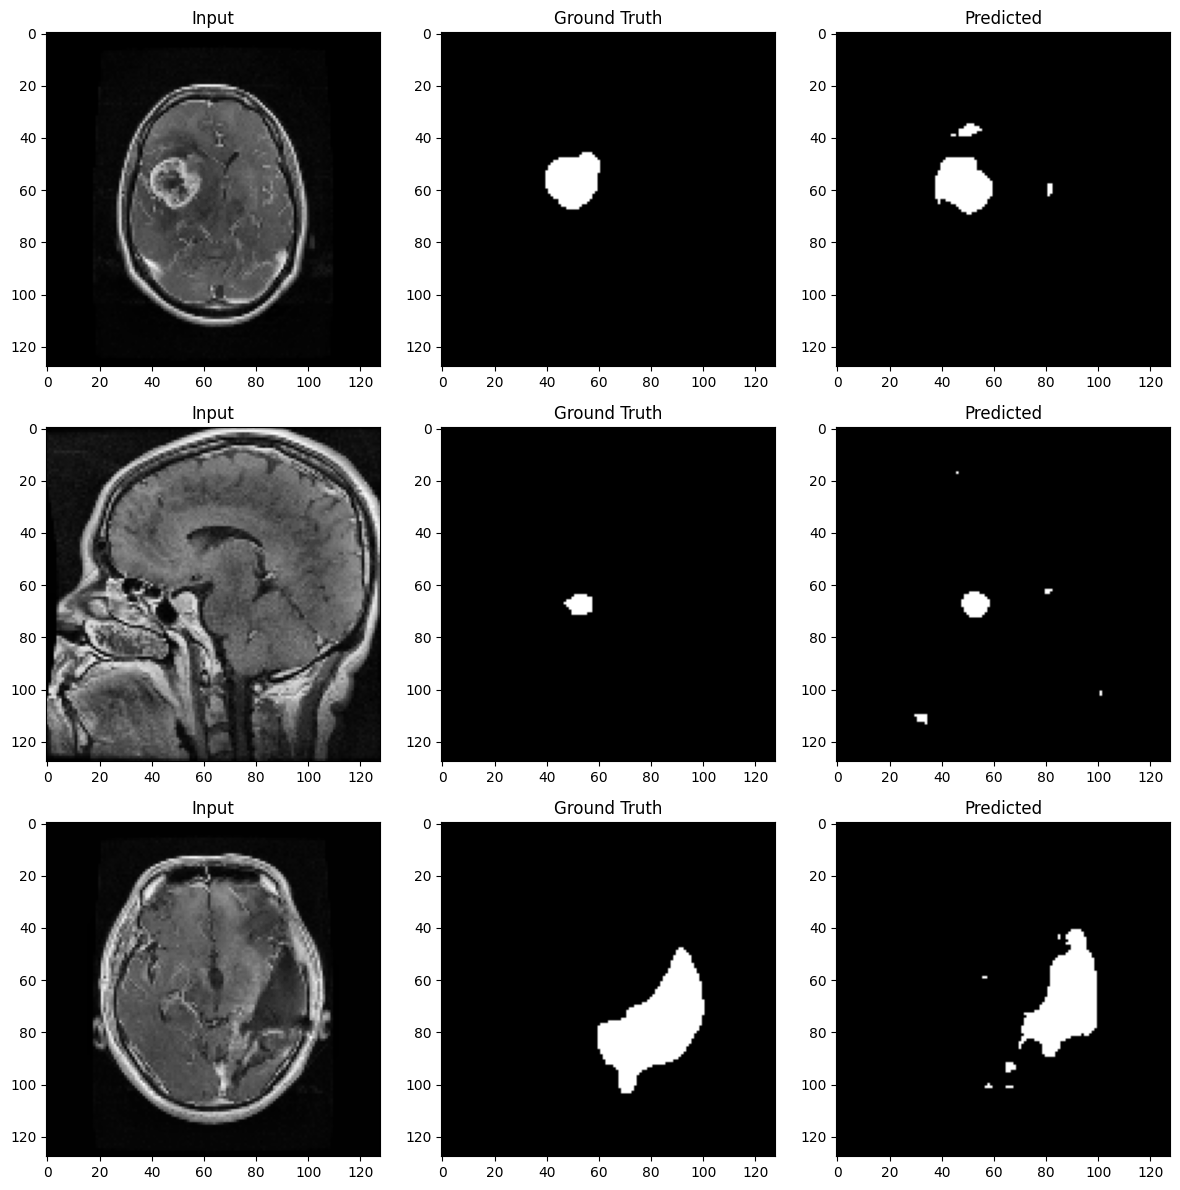

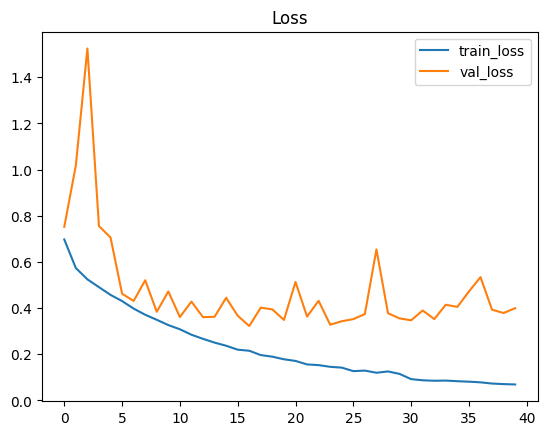

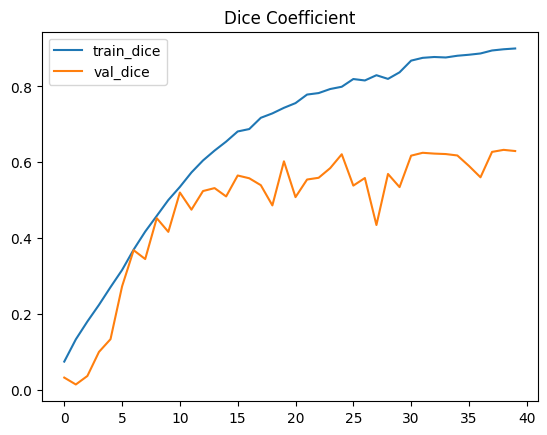

Epoch 1/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 60s 255ms/step - accuracy: 0.9380 - custom_iou: 0.0339 - custom_precision: 0.0343 - custom_recall: 0.8074 - dice_coef: 0.0597 - loss: 0.7491 - val_accuracy: 0.9431 - val_custom_iou: 0.0789 - val_custom_precision: 0.0800 - val_custom_recall: 0.8549 - val_dice_coef: 0.1317 - val_loss: 0.5854 - learning_rate: 1.0000e-04
Epoch 2/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9093 - custom_iou: 0.0781 - custom_precision: 0.0790 - custom_recall: 0.8831 - dice_coef: 0.1359 - loss: 0.5748 - val_accuracy: 0.8880 - val_custom_iou: 0.0835 - val_custom_precision: 0.0851 - val_custom_recall: 0.8138 - val_dice_coef: 0.1606 - val_loss: 0.6111 - learning_rate: 1.0000e-04
Epoch 3/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9337 - custom_iou: 0.0800 - custom_precision: 0.0813 - custom_recall: 0.8602 - dice_coef: 0.1476 - loss: 0.5701 - val_accuracy: 0.9732 - val_custom_iou: 0.1128 - val_custom_precision: 0.1207 - val_custom_recall: 0

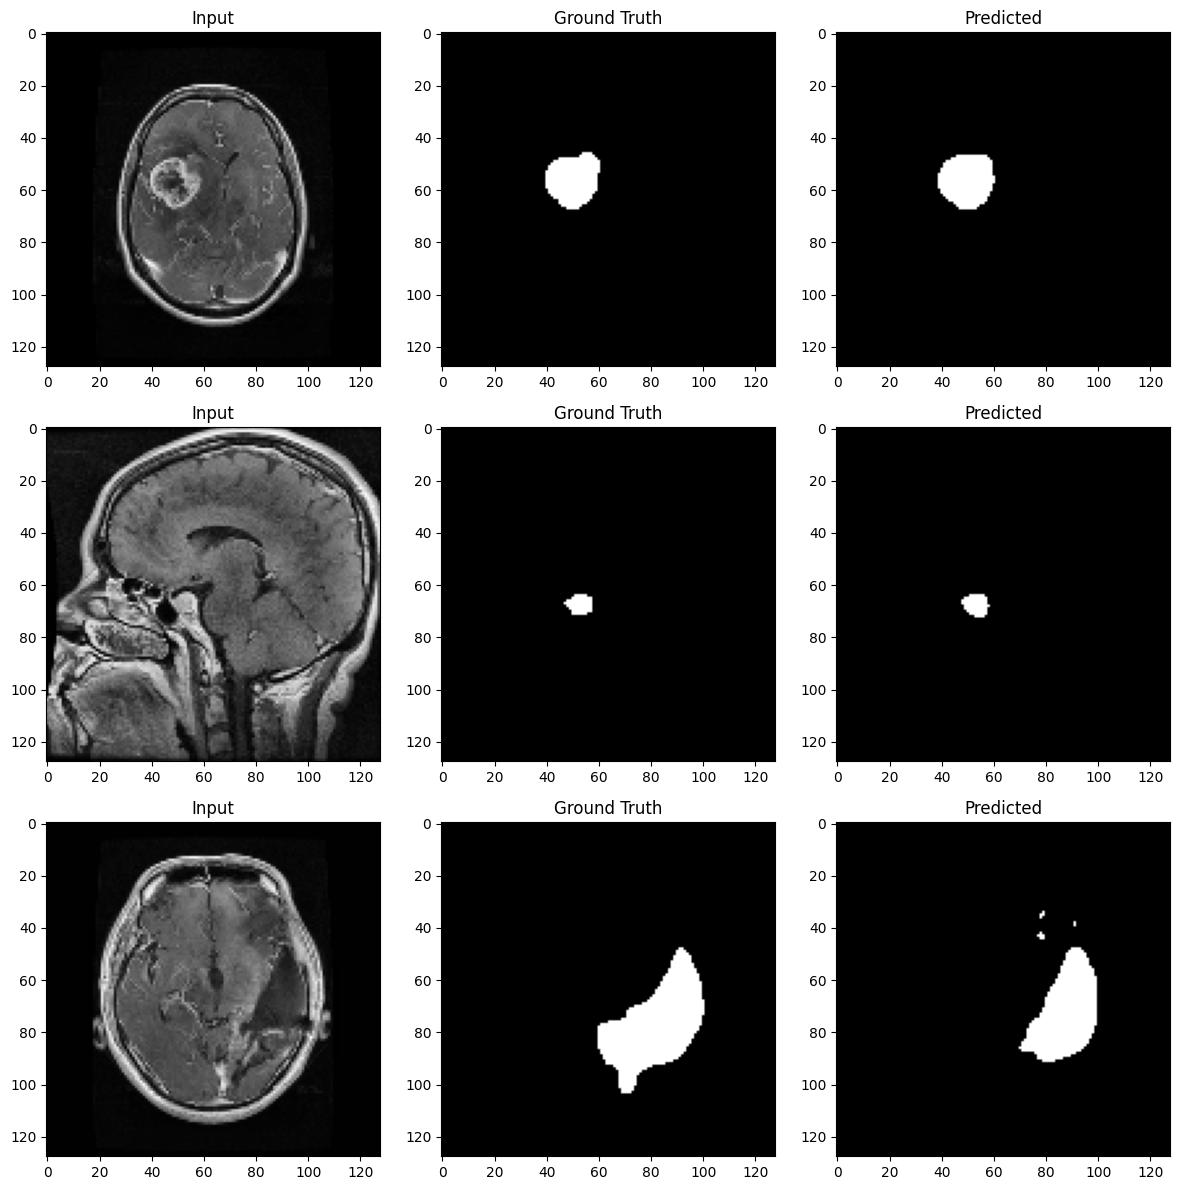

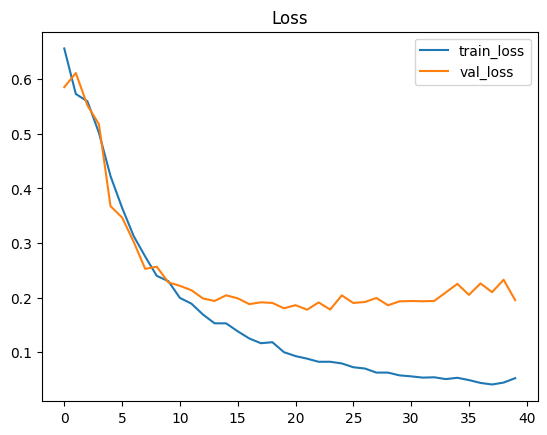

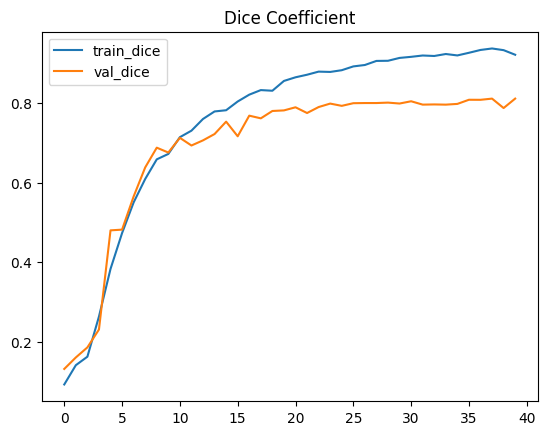

In [20]:
# --- 5. Run Training ---
# Choose one or both models to train:
segnet_model = build_segnet()
segnet_model, segnet_hist = compile_and_train(segnet_model, X_train, y_train, X_test, y_test, 'SegNet')

attunet_model = build_attention_unet()
attunet_model, attunet_hist = compile_and_train(attunet_model, X_train, y_train, X_test, y_test, 'AttentionUNet')

In [17]:
def compile_and_train(model, X_train, y_train, X_val, y_val, name):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=combined_loss,
        metrics=['accuracy', dice_coef, custom_precision, custom_recall, custom_iou]
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=10, mode='max', restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coef', factor=0.5, patience=5, mode='max', min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(f'best_{name}.keras', monitor='val_dice_coef', save_best_only=True, mode='max')
    ]
    history = model.fit(
        X_train, y_train,
        batch_size=16,
        epochs=40,
        validation_data=(X_val, y_val),
        callbacks=callbacks
    )
    print(f"\nEvaluating {name} on test set:")
    print(dict(zip(model.metrics_names, model.evaluate(X_val, y_val, verbose=0))))
    visualize_predictions(model, X_val, y_val)
    plot_training_curves(history)
    return model, history


In [32]:
from tensorflow.keras.utils import plot_model
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os


save_training_curves(segnet_hist, 'SegNet')
save_classification_metrics_and_confusion(segnet_model, X_test, y_test, 'SegNet')
save_validation_predictions(segnet_model, X_test, y_test, 'SegNet')

save_training_curves(attunet_hist, 'AttentionUNet')
save_classification_metrics_and_confusion(attunet_model, X_test, y_test, 'AttentionUNet')
save_validation_predictions(attunet_model, X_test, y_test, 'AttentionUNet')

Saved training curves for AttentionUNet.
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step
Classification report for AttentionUNet:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   9871395
           1       0.80      0.84      0.82    171997

    accuracy                           0.99  10043392
   macro avg       0.90      0.92      0.91  10043392
weighted avg       0.99      0.99      0.99  10043392

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Saved validation preds vs labels for AttentionUNet.


In [ ]:
save_model_architectures(segnet_model, attunet_model)